# 01 — Przetwarzanie wstępne

Notatnik przygotowuje wspólny zbiór segmentów audio dla wszystkich czterech modeli.
Wynikiem jest tablica przebiegów czasowych `X_{split}.npy` oraz manifest opisujący
przynależność każdego segmentu do nagrania, mówcy i klasy emocjonalnej.

Podziału na podzbiory dokonano na poziomie mówców, przed segmentacją. Odwrotna
kolejność rozdzieliłaby fragmenty tego samego nagrania pomiędzy zbiór treningowy
i testowy, co stanowiłoby wyciek informacji.

**Wyjście:** 30 568 segmentów z 7441 nagrań, 91 mówców

## 1. Konfiguracja

In [ ]:
from pathlib import Path

BASE = Path("/kaggle/input/datasets/ejlok1/cremad")
RAW_DIR = BASE / "AudioWAV"
DEMOGRAPHICS_CSV = BASE / "VideoDemographics.csv"    # opcjonalny, nieobecny w wykorzystanej wersji zbioru
OUT_DIR = Path("/kaggle/working")

SR = 16000
TRIM_TOP_DB = 30
SEG_SEC = 1.0
SEG_HOP_SEC = 0.5 
MIN_TAIL_RATIO = 0.6
PEAK_TARGET = 0.95
SEG_LEN = int(SEG_SEC * SR)
SEG_HOP = int(SEG_HOP_SEC * SR)

N_FFT, WIN_LENGTH, HOP_LENGTH = 512, 400, 160
WINDOW, CENTER = "hann", True
N_FRAMES = SEG_LEN // HOP_LENGTH + 1
N_BINS = N_FFT // 2 + 1

N_MELS, N_MFCC, FMIN, FMAX = 64, 40, 20, 8000
POWER_COMPRESSION = 0.3

SEED = 42
N_TEST_ACTORS, N_VAL_ACTORS = 14, 14

EMOTIONS = ["ANG", "DIS", "FEA", "HAP", "NEU", "SAD"]
EMOTION_PL = {"ANG":"złość","DIS":"wstręt","FEA":"strach",
              "HAP":"radość","NEU":"neutralny","SAD":"smutek"}
LABEL2ID = {e: i for i, e in enumerate(EMOTIONS)}
ID2LABEL = {i: e for e, i in LABEL2ID.items()}
N_CLASSES = len(EMOTIONS)

In [ ]:
import time, warnings


import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

rng = np.random.default_rng(SEED)

OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"częstotliwość probkowania : {SR} Hz")
print(f"długość segmentu          : {SEG_SEC} s ({SEG_LEN} próbek)")
print(f"przesunięcie okna         : {SEG_HOP_SEC} s ({SEG_HOP} próbek)")
print(f"kształt STFT segmentu     : ({N_BINS}, {N_FRAMES})")
print(f"klasy                     : {EMOTIONS}")

/usr/bin/python3
czestotliwosc probkowania : 16000 Hz
dlugosc segmentu          : 1.0 s (16000 probek)
przesuniecie okna         : 0.5 s (8000 probek)
ksztalt STFT segmentu     : (257, 101)
klasy                     : ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']


## 2. Manifest nagrań

Etykiety odczytywane są z nazw plików, zgodnie z konwencją zbioru CREMA-D:
`{aktor}_{zdanie}_{emocja}_{intensywność}.wav`. Wykorzystano emocję zamierzoną
przez aktora.

In [6]:
def build_manifest(raw_dir: Path) -> pd.DataFrame:
    rows = []
    for p in sorted(raw_dir.glob("*.wav")):
        parts = p.stem.split("_")
        if len(parts) != 4:
            print(f"[pominieto] nietypowa nazwa: {p.name}")
            continue
        actor, sentence, emotion, intensity = parts
        if emotion not in LABEL2ID:
            print(f"[pominieto] nieznana emocja: {p.name}")
            continue
        rows.append({
            "path": str(p),
            "file_id": p.stem,
            "actor": int(actor),
            "sentence": sentence,
            "emotion": emotion,
            "intensity": intensity,
            "label": LABEL2ID[emotion],
        })
    return pd.DataFrame(rows)


files = build_manifest(RAW_DIR)
print(f"znaleziono {len(files)} plikow, {files.actor.nunique()} aktorow")
display(files.head())
display(files.emotion.value_counts().rename("liczba nagran").to_frame())

znaleziono 7442 plikow, 91 aktorow


,path,file_id,actor,sentence,emotion,intensity,label
0,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...,1001_DFA_ANG_XX,1001,DFA,ANG,XX,0
1,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...,1001_DFA_DIS_XX,1001,DFA,DIS,XX,1
2,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...,1001_DFA_FEA_XX,1001,DFA,FEA,XX,2
3,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...,1001_DFA_HAP_XX,1001,DFA,HAP,XX,3
4,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...,1001_DFA_NEU_XX,1001,DFA,NEU,XX,4


,liczba nagran
emotion,
ANG,1271
DIS,1271
FEA,1271
HAP,1271
SAD,1271
NEU,1087


## 3. Podział na mówców

Podział przeprowadzono losowo, z ustalonym ziarnem. Wykorzystana kopia zbioru nie
zawiera metadanych demograficznych, wobec czego stratyfikacja względem płci nie
była możliwa.

In [ ]:
def split_actors(actors, demographics_csv=None):
    actors = np.array(sorted(actors))

    groups = {"all": actors}
    if demographics_csv is not None and Path(demographics_csv).exists():
        demo = pd.read_csv(demographics_csv)
        col_id = [c for c in demo.columns if "ActorID" in c][0]
        col_sex = [c for c in demo.columns if "Sex" in c][0]
        sex = demo.set_index(col_id)[col_sex].to_dict()
        groups = {}
        for a in actors:
            groups.setdefault(sex.get(a, "?"), []).append(a)
        groups = {k: np.array(v) for k, v in groups.items()}
        print("stratyfikacja wg plci:", {k: len(v) for k, v in groups.items()})
    else:
        print("podzial losowy bez stratyfikacji demograficznej")

    test, val, train = [], [], []
    n_groups = len(groups)
    for g in groups.values():
        g = g.copy()
        rng.shuffle(g)
        n_te = round(N_TEST_ACTORS / n_groups)
        n_va = round(N_VAL_ACTORS / n_groups)
        test.extend(g[:n_te])
        val.extend(g[n_te:n_te + n_va])
        train.extend(g[n_te + n_va:])

    return {"train": sorted(train), "val": sorted(val), "test": sorted(test)}


splits = split_actors(files.actor.unique(), DEMOGRAPHICS_CSV)
actor2split = {a: s for s, lst in splits.items() for a in lst}
files["split"] = files.actor.map(actor2split)

for s in ["train", "val", "test"]:
    print(f"{s:5s}: {len(splits[s]):3d} aktorow, {(files.split == s).sum():5d} nagran")

# kontrola rozlacznosci
assert not (set(splits["train"]) & set(splits["val"]))
assert not (set(splits["train"]) & set(splits["test"]))
assert not (set(splits["val"]) & set(splits["test"]))
print("\nzbiory mowcow sa rozlaczne")

brak VideoDemographics.csv - podzial losowy bez stratyfikacji
train:  63 aktorow,  5158 nagran
val  :  14 aktorow,  1142 nagran
test :  14 aktorow,  1142 nagran

zbiory mowcow sa rozlaczne


In [ ]:
import json

with open(OUT_DIR / "split_actors.json", "w", encoding="utf-8") as f:
    json.dump({s: sorted(int(a) for a in splits[s]) for s in
               ["train", "val", "test"]}, f, indent=2)

print(f"zapisano: {OUT_DIR / 'split_actors.json'}")
for s in ["train", "val", "test"]:
    print(f"  {s:5s} {len(splits[s]):2d} aktorów")

## 4. Rozkład klas w podzbiorach

In [ ]:
ct = pd.crosstab(files.split, files.emotion, normalize="index").round(3)
display(ct.loc[["train", "val", "test"]])

emotion,ANG,DIS,FEA,HAP,NEU,SAD
split,,,,,,
train,0.171,0.171,0.171,0.171,0.146,0.171
val,0.171,0.171,0.171,0.171,0.146,0.171
test,0.171,0.171,0.171,0.171,0.146,0.171


## 5. Segmentacja

Kolejne etapy: konwersja do sygnału monofonicznego 16 kHz, normalizacja szczytowa
do poziomu 0,95, usunięcie ciszy z początku i końca nagrania przy progu 30 dB
poniżej szczytu, podział na segmenty jednosekundowe z przesunięciem 0,5 s.

Zrezygnowano z wycinania pauz wewnętrznych: sklejanie fragmentów wprowadza
nieciągłość przebiegu, która w reprezentacji zespolonej objawia się skokiem kąta
fazowego.

In [9]:
def load_and_trim(path: str):
    y, _ = librosa.load(path, sr=SR, mono=True)
    if y.size == 0:
        return None
    peak = np.abs(y).max()
    if peak < 1e-6:
        return None
    y = y / peak * PEAK_TARGET
    y, _ = librosa.effects.trim(y, top_db=TRIM_TOP_DB)
    return y if y.size > 0 else None


def segment(y: np.ndarray):
    L, H = SEG_LEN, SEG_HOP
    if len(y) < L:
        return [np.pad(y, (0, L - len(y)))]
    segs, start = [], 0
    while start + L <= len(y):
        segs.append(y[start:start + L])
        start += H
    tail = y[start:]
    if len(tail) >= MIN_TAIL_RATIO * L:
        segs.append(np.pad(tail, (0, L - len(tail))))
    return segs

In [ ]:
t0 = time.time()
buffers = {"train": [], "val": [], "test": []}
meta_rows = []
skipped = []

for i, row in enumerate(files.itertuples(index=False), 1):
    y = load_and_trim(row.path)
    if y is None:
        skipped.append(row.file_id)
        continue
    for k, seg in enumerate(segment(y)):
        buffers[row.split].append(seg.astype(np.float32))
        meta_rows.append({
            "split": row.split,
            "idx": len(buffers[row.split]) - 1,
            "file_id": row.file_id,
            "seg_id": k,
            "actor": row.actor,
            "sentence": row.sentence,
            "emotion": row.emotion,
            "intensity": row.intensity,
            "label": row.label,
        })
    if i % 500 == 0:
        print(f"  {i}/{len(files)} plikow, {time.time() - t0:5.1f} s")

manifest = pd.DataFrame(meta_rows)
print(f"\ngotowe w {time.time() - t0:.1f} s")
print(f"pominiętych plików: {len(skipped)}" + (f"  {skipped}" if skipped else ""))
print(f"segmentow lacznie: {len(manifest)}")

  500/7442 plikow,  21.7 s
  1000/7442 plikow,  24.9 s
  1500/7442 plikow,  28.0 s
  2000/7442 plikow,  31.2 s
  2500/7442 plikow,  34.3 s
  3000/7442 plikow,  37.5 s
  3500/7442 plikow,  40.7 s
  4000/7442 plikow,  43.8 s
  4500/7442 plikow,  47.1 s
  5000/7442 plikow,  50.2 s
  5500/7442 plikow,  53.3 s
  6000/7442 plikow,  56.4 s
  6500/7442 plikow,  59.5 s
  7000/7442 plikow,  62.7 s

gotowe w 65.5 s
pominietych plikow (cisza / blad odczytu): 1
segmentow lacznie: 30568


## 6. Zapis danych

In [ ]:
for split, buf in buffers.items():
    X = np.stack(buf).astype(np.float32)
    out = OUT_DIR / f"X_{split}.npy"
    np.save(out, X)
    print(f"{out}  ->  {X.shape}, {X.nbytes / 1e6:6.1f} MB")

manifest.to_csv(OUT_DIR / "manifest.csv", index=False)
print(f"\n{OUT_DIR / 'manifest.csv'}  ->  {len(manifest)} wierszy")

/kaggle/working/X_train.npy  ->  (21151, 16000), 1353.7 MB
/kaggle/working/X_val.npy  ->  (4686, 16000),  299.9 MB
/kaggle/working/X_test.npy  ->  (4731, 16000),  302.8 MB

/kaggle/working/manifest.csv  ->  30568 wierszy


In [ ]:
manifest_test = manifest[manifest.split == "test"]
ids = sorted(manifest_test.file_id.unique())
(OUT_DIR / "test_ids.txt").write_text("\n".join(ids), encoding="utf-8")
print(f"zapisano {len(ids)} identyfikatorów nagrań testowych")

## 7. Statystyki zbioru

In [12]:
stat = (manifest.groupby("split")
        .agg(segmenty=("idx", "size"),
             nagrania=("file_id", "nunique"),
             aktorzy=("actor", "nunique"))
        .loc[["train", "val", "test"]])
stat["segm_na_nagranie"] = (stat.segmenty / stat.nagrania).round(2)
display(stat)

display(pd.crosstab(manifest.split, manifest.emotion).loc[["train", "val", "test"]])

,segmenty,nagrania,aktorzy,segm_na_nagranie
split,,,,
train,21151,5157,63,4.10
val,4686,1142,14,4.10
test,4731,1142,14,4.14


emotion,ANG,DIS,FEA,HAP,NEU,SAD
split,,,,,,
train,3106,4160,3565,3277,3108,3935
val,671,915,773,730,707,890
test,630,944,789,749,735,884


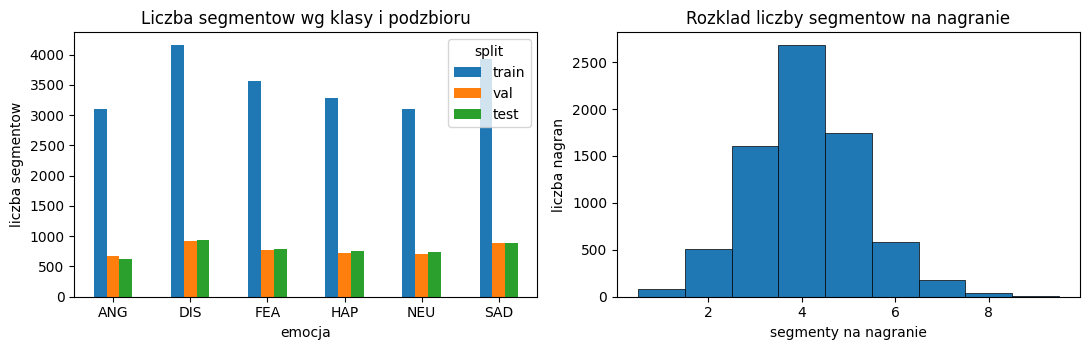

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

cnt = manifest.groupby(["split", "emotion"]).size().unstack().loc[["train", "val", "test"]]
cnt.T.plot(kind="bar", ax=ax[0], rot=0)
ax[0].set_title("Liczba segmentow wg klasy i podzbioru")
ax[0].set_xlabel("emocja"); ax[0].set_ylabel("liczba segmentow")

per_file = manifest.groupby("file_id").size()
ax[1].hist(per_file, bins=range(1, per_file.max() + 2), align="left",
           edgecolor="black", linewidth=0.5)
ax[1].set_title("Rozklad liczby segmentow na nagranie")
ax[1].set_xlabel("segmenty na nagranie"); ax[1].set_ylabel("liczba nagran")

plt.tight_layout(); plt.show()

## 8. Kontrola poprawności

Weryfikacja rozłączności mówców pomiędzy podzbiorami oraz zgodności wymiarów
zapisanych tablic.

In [14]:
# 1 - rozlacznosc mowcow
overlap = manifest.groupby("actor").split.nunique()
assert (overlap == 1).all(), "aktor wystepuje w wiecej niz jednym podzbiorze"

# 2 - rozlacznosc nagran
overlap_f = manifest.groupby("file_id").split.nunique()
assert (overlap_f == 1).all(), "segmenty jednego nagrania w roznych podzbiorach"

# 3 - stala dlugosc
for split in ["train", "val", "test"]:
    X = np.load(OUT_DIR / f"X_{split}.npy", mmap_mode="r")
    assert X.shape[1] == SEG_LEN
    assert X.shape[0] == (manifest.split == split).sum()

print("wszystkie kontrole przeszly poprawnie")

wszystkie kontrole przeszly poprawnie


## 9. Podgląd reprezentacji

plik 1002_DFA_ANG_XX | emocja: zlosc
STFT (257, 101) complex64 | MFCC (40, 101) | zespolony (257, 101) complex64


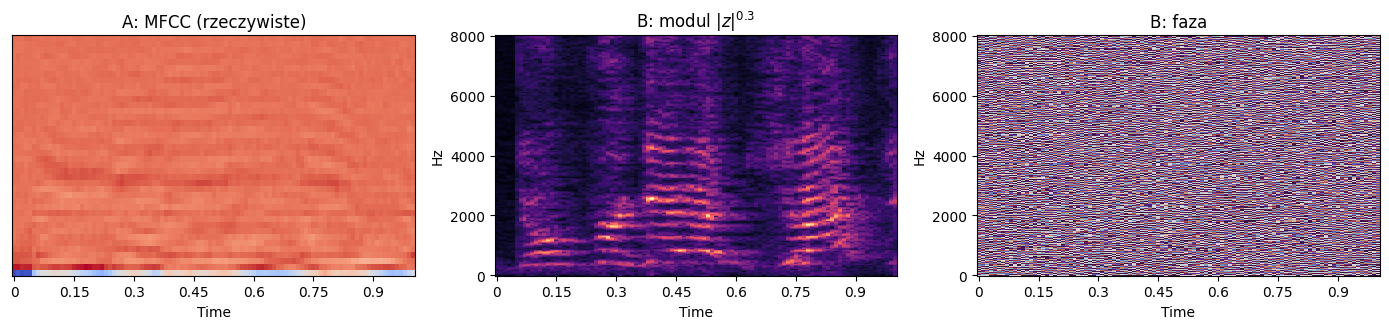

In [ ]:
X = np.load(OUT_DIR / "X_train.npy", mmap_mode="r")
i = 0
y = np.asarray(X[i])
row = manifest[manifest.split == "train"].iloc[i]

# wspolna transformata
Z = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH,
                 win_length=WIN_LENGTH, window=WINDOW, center=CENTER)

# sciezka A (rzeczywista)
mel = librosa.feature.melspectrogram(S=np.abs(Z) ** 2, sr=SR,
                                     n_mels=N_MELS, fmin=FMIN, fmax=FMAX)
mfcc = librosa.feature.mfcc(S=librosa.power_to_db(mel), n_mfcc=N_MFCC)

# sciezka B (zespolona)
Zc = (np.abs(Z) ** POWER_COMPRESSION) * np.exp(1j * np.angle(Z))

print(f"plik {row.file_id} | emocja: {EMOTION_PL[row.emotion]}")
print(f"STFT {Z.shape} {Z.dtype} | MFCC {mfcc.shape} | zespolony {Zc.shape} {Zc.dtype}")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
librosa.display.specshow(mfcc, sr=SR, hop_length=HOP_LENGTH,
                         x_axis="time", ax=ax[0])
ax[0].set_title("A: MFCC (rzeczywiste)")
librosa.display.specshow(np.abs(Zc), sr=SR, hop_length=HOP_LENGTH,
                         x_axis="time", y_axis="linear", ax=ax[1])
ax[1].set_title(r"B: modul $|z|^{0.3}$")
librosa.display.specshow(np.angle(Zc), sr=SR, hop_length=HOP_LENGTH,
                         x_axis="time", y_axis="linear", cmap="twilight", ax=ax[2])
ax[2].set_title("B: faza")
plt.tight_layout(); plt.show()